# Tutorial 9: What a Population Encodes

Everything so far used synthetic data, because you cannot check an estimator
without an answer to check against. This notebook uses real recordings: CA1
neurons from a rat running a maze, with position tracked throughout, in two
sessions from the same animal on two different mazes.

There is no ground truth here, and that changes the work. You cannot ask whether
an estimate is correct. You can only ask whether a claim is **defensible**, and
the answer comes from controls, contrasts and replication.

**So nothing below is computed because it can be.** Each section starts from a
question worth asking about this experiment, says what we expect and why, and
then tests it. Two of the expectations do not survive, which is the more useful
half of the notebook.

| # | Question | What we expect, and why |
|---|---|---|
| 1 | Does the population carry information about position? | These are place cells. If the pipeline says no, the pipeline is wrong. |
| 2 | Is that number an artifact of how we cut the data? | Overlapping windows plus a careless split would inflate it. |
| 3 | Does more of the population tell us more? | Place fields tile the maze redundantly, so information should grow and then flatten. |
| 4 | At what timing resolution does the code live? | If timing matters, jittering spikes should destroy the information. |
| 5 | What shape is the represented space? | A linear track is an interval; a circular maze is a ring. Different topologies should look different. |

**A note on which quantities appear here.** Everything below is a single mutual
information, one training run, no subtraction. Quantities built as a
*difference* of two estimates amplify the error of both; Tutorial 6 measures
transfer entropy's amplification at 25 to 40 times and shows its reported
direction reversing when a setting changes. On synthetic data you can check that
damage against a known answer. Here you cannot, so we stay with quantities whose
error we can reason about.

**Runtime.** This notebook runs the full protocol rather than a reduced one:
three repeats everywhere, a 30-permutation null on each maze, and the population
sweep at three independent random draws per size. That takes roughly twenty-five
minutes. The alternative was printing tighter-looking error bars than the
measurement actually supports.

## 0. Setup

In [1]:
import logging
import pickle
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import neural_mi as nmi
from neural_mi.utils import compute_cross_covariance_rotation

# INFO-level progress would dominate the committed output. Warnings stay on:
# the retention warning in section 2 is the point of section 2.
logging.getLogger('neural_mi').setLevel(logging.WARNING)

SCALE = 1
np.random.seed(0)

WIN, STEP, BIN, MCOV = 0.5, 0.125, 0.1, 0.9    # window, step, spike bin, coverage
REPS = [0, 1, 2]

def load(name):
    with open(f'data/hippocampus_{name}.pkl', 'rb') as f:
        d = pickle.load(f)
    spikes = [np.asarray(s) for s in d['spikes_real']]           # spike times, seconds
    pos = np.asarray(d['pos_1d'], dtype='float32')[:, None]      # (n_samples, 1), metres
    pos_t = np.asarray(d['pos_times_real'], dtype='float64')     # (n_samples,), seconds
    return spikes, pos, pos_t, d

def processing_for(pos_t, binned=True):
    xp = {'window_size': WIN, 'step_size': STEP}
    if binned:
        xp['bin_size'] = BIN
    else:
        xp['drop_empty_windows'] = False
    return nmi.Processing(
        x='spike', x_params=xp,
        y='continuous', y_params={'window_size': WIN, 'step_size': STEP,
                                  'min_coverage_fraction': MCOV},
        y_time=pos_t)

MODEL = dict(embedding_model='mlp', embedding_dim=16, hidden_dim=256)
TRAIN = nmi.Training(n_epochs=int(120 * SCALE), patience=35)

for name in ('linear', 'circular'):
    _, pos, pos_t, d = load(name)
    print(f"{name:<9} {d['n_neurons']:>4} neurons   position {pos.min():.2f}-{pos.max():.2f} m"
          f"   {d['maze_duration']:.0f} s session")

linear     120 neurons   position 0.00-1.60 m   2068 s session
circular    92 neurons   position 0.00-2.90 m   2674 s session


## 1. What the data lets us ask

Before any estimate, look at when the position signal actually exists. This is
not a formality: it decides which questions are answerable.

linear    covered    265s of   1952s (13.6%)    138 fragments, median  1.9s, max   6.9s
circular  covered   1563s of   2646s (59.1%)    446 fragments, median  1.6s, max  31.4s


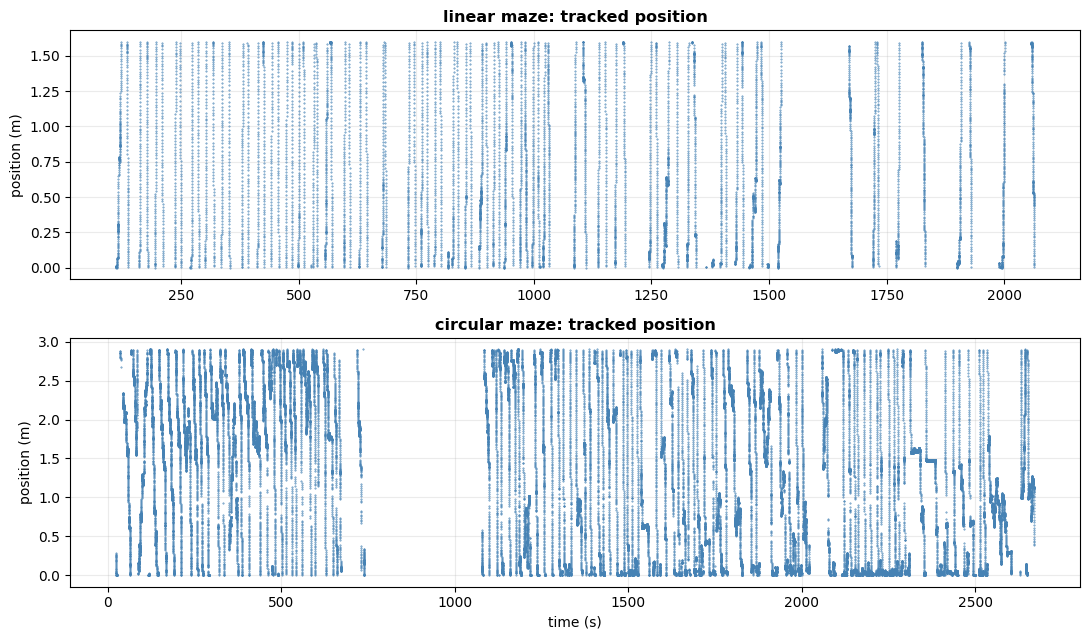

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6.5))
for ax, name in zip(axes, ('linear', 'circular')):
    _, pos, pos_t, d = load(name)
    dt = np.diff(pos_t)
    md_ = float(np.median(dt))
    span, covered = pos_t.max() - pos_t.min(), len(pos_t) * md_
    gap = dt > 5 * md_
    idx = np.flatnonzero(gap)
    starts = np.concatenate([[0], idx + 1]); ends = np.concatenate([idx, [len(pos_t) - 1]])
    durs = pos_t[ends] - pos_t[starts]
    print(f"{name:<9} covered {covered:6.0f}s of {span:6.0f}s ({100*covered/span:4.1f}%)   "
          f"{len(durs):>4} fragments, median {np.median(durs):4.1f}s, max {durs.max():5.1f}s")
    ax.plot(pos_t, pos[:, 0], '.', ms=0.8, color='steelblue')
    ax.set_title(f"{name} maze: tracked position", fontsize=11.5, fontweight='bold')
    ax.set_ylabel('position (m)')
    ax.grid(alpha=0.25)
axes[1].set_xlabel('time (s)')
plt.tight_layout()
plt.show()

**Neither session is a continuous block.** Position exists only while the animal
is running the maze; the gaps are everything else. The linear session covers
about a seventh of its span in fragments of a couple of seconds; the circular
session covers well over half of its span, in longer stretches.

Two consequences, and the second is the one people miss:

- **A window is usable only where every signal it pairs has data.** Gaps in one
  signal remove windows for all of them.
- **Any quantity that slides a window along the raw index is unsafe here.** With
  fragments this short, such a window would silently pair samples seconds apart
  as though they were adjacent. That rules out the self-prediction quantities of
  Tutorial 5 on this recording. It does not rule out anything below, because
  every measurement here pairs a spike window with a position window over the
  same interval rather than stepping through the index.

## 2. Windowing, and the retention to check first

`min_coverage_fraction` sets how much of a continuous window must be real
samples rather than interpolation across a gap. Watch what it costs.

In [3]:
for name in ('linear', 'circular'):
    spikes, pos, pos_t, d = load(name)
    print(f"--- {name} maze")
    for mcov in (None, 0.5, 0.9):
        yp = {'window_size': WIN, 'step_size': STEP}
        if mcov is not None:
            yp['min_coverage_fraction'] = mcov
        ds = nmi.data.handler.create_dataset(
            x_data=spikes, y_data=pos, y_time=pos_t,
            processor_type_x='spike',
            processor_params_x={'window_size': WIN, 'step_size': STEP, 'bin_size': BIN},
            processor_type_y='continuous', processor_params_y=yp)
        print(f"    min_coverage_fraction={str(mcov):<5}  built {ds.n_windows_built:>6}  "
              f"kept {ds.n_windows_retained:>6}  retention {100*ds.window_retention:5.1f}%")
    print(f"    spike tensor {tuple(ds.x_data.shape)}, position tensor {tuple(ds.y_data.shape)}")

--- linear maze


2026-08-27 03:12:32 - neural_mi - WARNING - Window coverage validation kept 4741 of 31237 windows (15.2%), dropped by Y (26496). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


2026-08-27 03:12:32 - neural_mi - WARNING - ContinuousWindowDataset: 963/4741 retained window(s) have over 30% of their samples bridged by interpolation across a gap more than 3x the typical inter-sample period. These windows passed min_coverage_fraction (enough raw timestamps are nearby) but much of their content may be fabricated by np.interp. Consider raising min_coverage_fraction or pre-collapsing large gaps in your data.


    min_coverage_fraction=None   built  31237  kept   4741  retention  15.2%


2026-08-27 03:12:32 - neural_mi - WARNING - ContinuousWindowDataset: 404/4180 retained window(s) have over 30% of their samples bridged by interpolation across a gap more than 3x the typical inter-sample period. These windows passed min_coverage_fraction (enough raw timestamps are nearby) but much of their content may be fabricated by np.interp. Consider raising min_coverage_fraction or pre-collapsing large gaps in your data.


...

2026-08-27 03:12:34 - neural_mi - WARNING - ContinuousWindowDataset: 3076/26799 retained window(s) have over 30% of their samples bridged by interpolation across a gap more than 3x the typical inter-sample period. These windows passed min_coverage_fraction (enough raw timestamps are nearby) but much of their content may be fabricated by np.interp. Consider raising min_coverage_fraction or pre-collapsing large gaps in your data.


    min_coverage_fraction=None   built  42339  kept  26799  retention  63.3%


2026-08-27 03:12:35 - neural_mi - WARNING - ContinuousWindowDataset: 1366/25085 retained window(s) have over 30% of their samples bridged by interpolation across a gap more than 3x the typical inter-sample period. These windows passed min_coverage_fraction (enough raw timestamps are nearby) but much of their content may be fabricated by np.interp. Consider raising min_coverage_fraction or pre-collapsing large gaps in your data.


    min_coverage_fraction=0.5    built  42339  kept  25085  retention  59.2%


    min_coverage_fraction=0.9    built  42339  kept  21341  retention  50.4%
    spike tensor (21341, 92, 5), position tensor (21341, 1, 21)


**Most windows are discarded, and that is correct.** Retention tracks how much
of each session has usable position, so the linear maze keeps around a tenth and
the circular maze around half. The library reports this rather than proceeding
quietly, which is the behaviour you want.

Raising `min_coverage_fraction` removes windows whose contents were mostly
manufactured by interpolating across a gap. Those would otherwise contribute
confident-looking position trajectories that were never measured.

**Report retention alongside any estimate from real data.** A per-window figure
is per *retained* window, and the retained windows are a selected subset.

## 3. Question 1: does the population carry position information?

These are place cells, so the expected answer is yes. The point of asking is
that it establishes the pipeline works before anything subtler is attempted, and
it gives the permutation null something to be compared against.

The null breaks the pairing between activity and position, re-runs the whole
pipeline, and reports what the machinery returns when there is nothing to find.

In [4]:
N_PERM = int(30 * SCALE)
main = {}

for name in ('linear', 'circular'):
    spikes, pos, pos_t, d = load(name)
    P = processing_for(pos_t)
    t0 = time.time()
    r = nmi.run(spikes, pos, mode='estimate', processing=P,
                training=TRAIN, model=nmi.Model(**MODEL),
                permutation_test=True, n_permutations=N_PERM,
                n_workers=8, seed=0, show_progress=False)
    null = np.array([float(v) for v in r.details['null_distribution']])
    p = (1 + np.sum(null >= r.mi_estimate)) / (1 + len(null))
    main[name] = {'mi': float(r.mi_estimate), 'null_max': float(null.max()), 'p': float(p)}
    print(f"{name:<9} MI = {r.mi_estimate:.3f} bits per {WIN}s window   "
          f"null mean {null.mean():.4f}, max {null.max():.4f}   p = {p:.3f}   "
          f"({time.time()-t0:.0f}s)")

2026-08-27 03:12:35 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


neural_mi/run.py:389: UserWarning: permutation_test=True with n_permutations=30. This is insufficient to estimate a reliable p-value or null distribution. Use n_permutations >= 100 for meaningful statistical inference.
  return _run_flat(x_data, y_data, **flat, **analysis_kwargs)


2026-08-27 03:12:36 - neural_mi - WARNING - Window coverage validation kept 3332 of 31237 windows (10.7%), dropped by Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0102 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0046 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0001 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0026 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results =

neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0010 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0104 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0014 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0026 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results =

...

neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0012 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0001 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0003 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0016 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0003 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0007 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0010 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


circular  MI = 3.033 bits per 0.5s window   null mean 0.0010, max 0.0138   p = 0.032   (178s)


**Both populations carry position information, overwhelmingly.** The real
estimate sits one to two orders of magnitude above the largest of thirty
shuffled runs.

Two things to read carefully.

**The units are bits per window, and the window is part of the quantity.** This
is not "what the population knows about position" in any window-free sense.
Tutorial 4 shows why: windowed MI is extensive, so the number grows with window
size without bound. Quote it as bits per 0.5 s window or not at all.

**`p` is at its floor.** With 30 permutations the smallest attainable p-value is
`1/31`, about 0.032, because the observed value is counted among the
possibilities. A smaller p needs more permutations, not a stronger effect. To
report `p < 0.01` you need at least 100.

## 4. Question 2: is that number an artifact of how we cut the data?

At `step_size=0.125` with `window_size=0.5`, consecutive windows overlap by 75%.
A random split scatters near-duplicate windows across train and test, so the
critic can recall rather than generalise. Blocked splitting keeps contiguous
blocks together.

This is the Tutorial 3 lesson, now on real data and in two independent
recordings.

In [5]:
split_res = {}
for name in ('linear', 'circular'):
    spikes, pos, pos_t, d = load(name)
    P = processing_for(pos_t)
    for split in ('blocked', 'random'):
        vals = []
        for rep in REPS:
            r = nmi.run(spikes, pos, mode='estimate', processing=P,
                        training=TRAIN, model=nmi.Model(**MODEL),
                        split=nmi.Split(mode=split),
                        n_workers=1, seed=rep, show_progress=False)
            vals.append(float(r.mi_estimate))
        split_res[(name, split)] = (float(np.mean(vals)), float(np.std(vals, ddof=1)))
        print(f"  {name:<9} split={split:<8} MI = {np.mean(vals):.3f} +/- {np.std(vals,ddof=1):.3f}")

print()
for name in ('linear', 'circular'):
    b, bs = split_res[(name, 'blocked')]
    r_, rs = split_res[(name, 'random')]
    se = np.sqrt(bs**2 + rs**2) / np.sqrt(len(REPS))
    print(f"  {name:<9} inflation from random splitting: {r_-b:+.3f} bits "
          f"(2se = {2*se:.3f})  {'significant' if abs(r_-b) > 2*se else 'ns'}")

2026-08-27 03:16:17 - neural_mi - WARNING - Window coverage validation kept 3332 of 31237 windows (10.7%), dropped by Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


2026-08-27 03:16:24 - neural_mi - WARNING - Window coverage validation kept 3332 of 31237 windows (10.7%), dropped by Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


2026-08-27 03:16:30 - neural_mi - WARNING - Window coverage validation kept 3332 of 31237 windows (10.7%), dropped by Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


  linear    split=blocked  MI = 4.661 +/- 0.391


2026-08-27 03:16:36 - neural_mi - WARNING - Window coverage validation kept 3332 of 31237 windows (10.7%), dropped by Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


2026-08-27 03:16:43 - neural_mi - WARNING - Window coverage validation kept 3332 of 31237 windows (10.7%), dropped by Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


2026-08-27 03:16:51 - neural_mi - WARNING - Window coverage validation kept 3332 of 31237 windows (10.7%), dropped by Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


  linear    split=random   MI = 5.781 +/- 0.302


  circular  split=blocked  MI = 3.260 +/- 0.257


  circular  split=random   MI = 4.450 +/- 0.312

  linear    inflation from random splitting: +1.120 bits (2se = 0.570)  significant
  circular  inflation from random splitting: +1.190 bits (2se = 0.466)  significant


**Random splitting inflates the estimate in both recordings, by about the same
amount.** Nothing about the data changed. The extra bits come from test windows
that overlap training windows.

That it replicates across two independent sessions, with different neuron counts
and different mazes, is what makes it convincing. The effect tracks the
**windowing**, which is shared, rather than anything about either recording.

`Split(mode='blocked')` is the default for this reason.

## 5. Question 3: does more of the population tell us more?

Place fields tile the maze, so many cells carry overlapping information about
position. The expectation is that information grows with population size and
then flattens as redundancy sets in.

**Neurons are drawn at random, not by firing rate or variance.** Selecting the
most active units selects on a statistic correlated with what is being measured.
Section 7 shows what that costs when it is done wrong.

In [6]:
SIZES = [5, 10, 20, 40, 92]
scaling = {}

for name in ('linear', 'circular'):
    spikes, pos, pos_t, d = load(name)
    P = processing_for(pos_t)
    print(f"--- {name} maze ({d['n_neurons']} neurons available)")
    print(f"    {'n':>4} {'MI':>8} {'sd':>7} {'held-out':>9} {'saturation':>11} {'retention':>10}")
    for n in SIZES:
        if n > d['n_neurons']:
            continue
        tr, te, sat, ret = [], [], [], []
        for draw in REPS:
            rng = np.random.default_rng(500 + draw)
            idx = sorted(rng.permutation(d['n_neurons'])[:n])       # random draw
            r = nmi.run([spikes[i] for i in idx], pos, mode='estimate', processing=P,
                        training=TRAIN, model=nmi.Model(**MODEL),
                        n_workers=1, seed=draw, show_progress=False)
            det = r.details
            tr.append(float(r.mi_estimate)); te.append(float(det['test_mi']))
            sat.append(float(det['test_saturation'])); ret.append(float(det['window_retention']))
        scaling[(name, n)] = (float(np.mean(tr)), float(np.std(tr, ddof=1)),
                              float(np.mean(sat)), float(np.mean(ret)))
        print(f"    {n:>4} {np.mean(tr):>8.3f} {np.std(tr,ddof=1):>7.3f} {np.mean(te):>9.3f} "
              f"{np.mean(sat):>11.3f} {np.mean(ret):>10.3f}")

2026-08-27 03:20:00 - neural_mi - WARNING - Window coverage validation kept 2989 of 31237 windows (9.6%), dropped by X (15234) and Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


--- linear maze (120 neurons available)
       n       MI      sd  held-out  saturation  retention


2026-08-27 03:20:06 - neural_mi - WARNING - Window coverage validation kept 1809 of 31237 windows (5.8%), dropped by X (12171) and Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


2026-08-27 03:20:08 - neural_mi - WARNING - Window coverage validation kept 3079 of 31237 windows (9.9%), dropped by X (5689) and Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


2026-08-27 03:20:13 - neural_mi - WARNING - Window coverage validation kept 3248 of 31237 windows (10.4%), dropped by X (5417) and Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


...

2026-08-27 03:24:45 - neural_mi - WARNING - Window coverage validation kept 20615 of 42339 windows (48.7%), dropped by X (1773) and Y (20994). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


      20    2.022   0.381     1.171       0.106      0.483


2026-08-27 03:26:05 - neural_mi - WARNING - Window coverage validation kept 21163 of 42339 windows (50.0%), dropped by X (330) and Y (20994). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


      40    2.869   0.170     1.732       0.157      0.501


      92    3.260   0.257     1.765       0.160      0.504


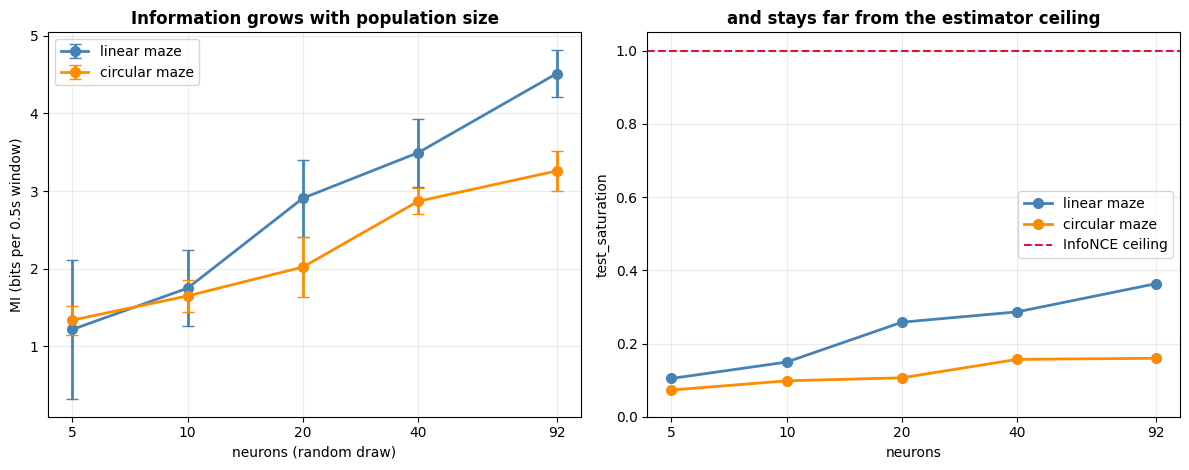

increment per doubling of population:
  linear    +0.53  +1.16  +0.59  +1.02
  circular  +0.31  +0.37  +0.85  +0.39


In [7]:
fig, (ax_mi, ax_sat) = plt.subplots(1, 2, figsize=(12, 4.8))
for name, colour in (('linear', 'steelblue'), ('circular', 'darkorange')):
    ns = [n for n in SIZES if (name, n) in scaling]
    mi = [scaling[(name, n)][0] for n in ns]
    sd = [scaling[(name, n)][1] for n in ns]
    sat = [scaling[(name, n)][2] for n in ns]
    ax_mi.errorbar(ns, mi, yerr=sd, fmt='o-', color=colour, lw=2, ms=7,
                   capsize=4, label=f'{name} maze')
    ax_sat.plot(ns, sat, 'o-', color=colour, lw=2, ms=7, label=f'{name} maze')
ax_mi.set_xscale('log', base=2); ax_mi.set_xticks(SIZES)
ax_mi.set_xticklabels([str(n) for n in SIZES])
ax_mi.set_xlabel('neurons (random draw)'); ax_mi.set_ylabel(f'MI (bits per {WIN}s window)')
ax_mi.set_title('Information grows with population size', fontsize=12, fontweight='bold')
ax_mi.legend(); ax_mi.grid(alpha=0.25)
ax_sat.axhline(1.0, color='crimson', ls='--', lw=1.5, label='InfoNCE ceiling')
ax_sat.set_xscale('log', base=2); ax_sat.set_xticks(SIZES)
ax_sat.set_xticklabels([str(n) for n in SIZES])
ax_sat.set_xlabel('neurons'); ax_sat.set_ylabel('test_saturation')
ax_sat.set_title('and stays far from the estimator ceiling', fontsize=12, fontweight='bold')
ax_sat.set_ylim(0, 1.05); ax_sat.legend(); ax_sat.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("increment per doubling of population:")
for name in ('linear', 'circular'):
    ns = [n for n in SIZES if (name, n) in scaling]
    mi = [scaling[(name, n)][0] for n in ns]
    print(f"  {name:<9} " + "  ".join(f"{mi[i]-mi[i-1]:+.2f}" for i in range(1, len(mi))))

**Information keeps growing, and the increments per doubling do not shrink.**
That is the signature of roughly logarithmic growth: each additional *neuron*
adds less than the last, but the population does not saturate anywhere in the
range we can test.

That is a weaker claim than "the code is redundant and saturates", and it is the
one the data supports. Note what had to be ruled out to say even this much:

**The estimator ceiling is not responsible.** `test_saturation` is the fraction
of the InfoNCE ceiling the estimate reached (Tutorial 10 covers the ceiling
itself). It stays far below 1 throughout, so the curve is not being flattened by
the estimator running out of headroom. Had saturation been climbing toward 1,
this whole section would have been uninterpretable.

**One confound remains, and it is worth stating rather than hiding.** Retention
rises with neuron count, because a spike window with no spikes in it is dropped
and sparser populations produce more silent windows. So the points on this curve
are estimated over slightly different window sets, and are not estimates of
exactly the same quantity. That is a genuine subtlety of population scaling with
spike data, not a fixable bug.

## 6. Question 4: at what timing resolution does the code live?

`mode='precision'` jitters spike times by increasing amounts and watches when
the information degrades. If position is carried by precise spike timing, small
jitters should hurt. If it is carried by firing rate, only jitters large enough
to move spikes between windows should matter.

**Two settings make or break this analysis.** Use `corruption_method='noise'`,
which is jitter; the default `'rounding'` snaps values to a grid instead. And do
**not** set `bin_size`: binning replaces spike times with counts, so there is no
timing left to corrupt, and the sweep will return a flat line that looks like a
result.

In [8]:
TAUS = [0.0, 0.01, 0.05, 0.15, 0.4, 1.0, 2.5]
prec_res = {}

for name in ('linear', 'circular'):
    spikes, pos, pos_t, d = load(name)
    P = processing_for(pos_t, binned=False)      # unbinned: the tensor holds spike times
    curves = []
    for rep in REPS:
        r = nmi.run(spikes, pos, mode='precision', processing=P,
                    precision=nmi.Precision(tau_grid=TAUS, corrupt_target='x',
                                            corruption_method='noise',
                                            threshold_ratio=0.9),
                    training=TRAIN, model=nmi.Model(**MODEL),
                    n_workers=6, seed=rep, show_progress=False)
        g = r.dataframe.groupby('tau')['train_mi'].mean()
        curves.append(list(g.values))
        taus = list(g.index)
    arr = np.array(curves)
    prec_res[name] = (taus, arr.mean(0), arr.std(0, ddof=1))
    print(f"--- {name} maze")
    for i, t in enumerate(taus):
        print(f"    jitter {t*1000:>6.0f} ms   MI = {arr[:,i].mean():6.3f} +/- {arr[:,i].std(ddof=1):.3f}")

2026-08-27 03:27:50 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


2026-08-27 03:27:50 - neural_mi - WARNING - Window coverage validation kept 3332 of 31237 windows (10.7%), dropped by Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


2026-08-27 03:27:51 - neural_mi - WARNING - Large first embedding layer detected: input_dim_x=4800 x hidden_dim=256 = 1,228,800 parameters. This may cause overfitting on small datasets. Consider reducing window_size, hidden_dim, or using a different embedding model.


2026-08-27 03:27:51 - neural_mi - WARNING - Custom train_indices and test_indices were provided. The split_mode, train_fraction, n_test_blocks, and split_gap_fraction parameters will be ignored for this run.


2026-08-27 03:28:31 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


...

2026-08-27 03:32:56 - neural_mi - WARNING - Custom train_indices and test_indices were provided. The split_mode, train_fraction, n_test_blocks, and split_gap_fraction parameters will be ignored for this run.


2026-08-27 03:36:05 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


2026-08-27 03:36:05 - neural_mi - WARNING - Large first embedding layer detected: input_dim_x=3496 x hidden_dim=256 = 894,976 parameters. This may cause overfitting on small datasets. Consider reducing window_size, hidden_dim, or using a different embedding model.


2026-08-27 03:36:05 - neural_mi - WARNING - Custom train_indices and test_indices were provided. The split_mode, train_fraction, n_test_blocks, and split_gap_fraction parameters will be ignored for this run.


--- circular maze
    jitter      0 ms   MI =  3.788 +/- 0.188
    jitter     10 ms   MI =  3.793 +/- 0.216
    jitter     50 ms   MI =  3.799 +/- 0.214
    jitter    150 ms   MI =  3.784 +/- 0.215
    jitter    400 ms   MI =  3.698 +/- 0.208
    jitter   1000 ms   MI =  3.140 +/- 0.122
    jitter   2500 ms   MI = -0.710 +/- 0.652


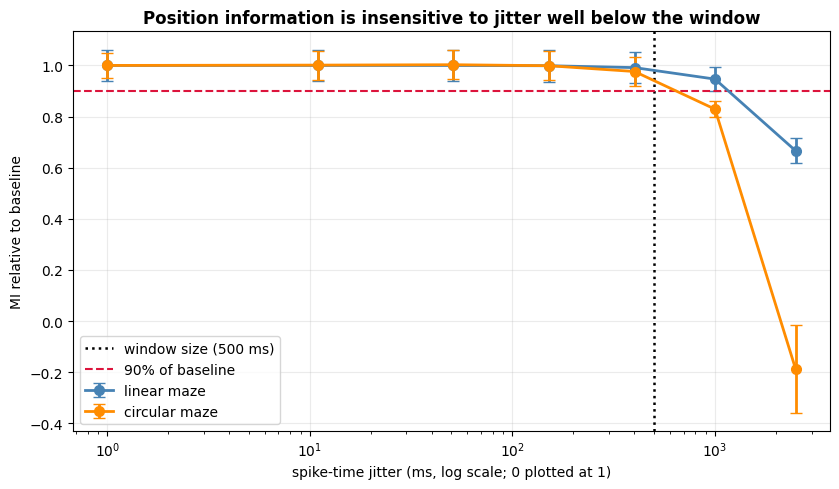

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for name, colour in (('linear', 'steelblue'), ('circular', 'darkorange')):
    taus, m, s = prec_res[name]
    base = m[0]
    ax.errorbar(np.array(taus)*1000 + 1, m/base, yerr=s/base, fmt='o-', color=colour,
                lw=2, ms=7, capsize=4, label=f'{name} maze')
ax.axvline(WIN*1000, color='k', ls=':', lw=1.8, label=f'window size ({WIN*1000:.0f} ms)')
ax.axhline(0.9, color='crimson', ls='--', lw=1.5, label='90% of baseline')
ax.set_xscale('log')
ax.set_xlabel('spike-time jitter (ms, log scale; 0 plotted at 1)')
ax.set_ylabel('MI relative to baseline')
ax.set_title('Position information is insensitive to jitter well below the window',
             fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Sub-window jitter costs nothing; the collapse comes well beyond the window.**
Jitters from 10 to 150 ms leave the estimate untouched, within a few thousandths
of a bit. The first measurable loss is at 400 ms, and it is under 1% on the
linear session and about 2% on the circular. At 1 s, twice the window, the cost
is roughly 5% and 17%. Only at 2.5 s, five times the window, does the code come
apart: the linear session loses a third of its information and the circular one
loses all of it, returning a negative estimate, which is InfoNCE's way of saying
it found nothing to recover.

The window is the key to reading this. A jitter much smaller than the window
moves a spike *within* its window; a jitter several times the window scatters it
across many. That the estimate is indifferent to the first means the code here is
a **rate code at the window scale**: what matters is that a spike occurred in
this window, not where in it.

Note that the breakdown is gradual and sets in above the window rather than at
it. Jitter of exactly one window width does not swap a spike cleanly into its
neighbour; it moves each spike by a random amount, so a spike near a window's
centre usually stays put. Scrambling the rate profile takes a jitter that is
large compared with the window, which is what 2.5 s delivers.

**This is a statement about the code at this window size, not about the
hippocampus.** A 50 ms window would ask a different question and could well give
a different answer.

## 7. Question 5: what shape is the represented space?

This is the question the two mazes exist to answer, and it is the one that does
not work.

A linear track is an interval. A circular maze is a ring: arc length 0 and the
maximum are the same physical place. A circle cannot be embedded in one
dimension. So if the population's representation reflects the environment's
shape, the two should look different, and the circular one should close.

The embedding needs one preliminary. A raw embedding's axes are **arbitrary**:
with `embedding_dim=8` the network may express the same manifold under any
rotation, so dimensions 0 and 1 mean nothing in particular. `mode='dimensionality'`
creates an ordering by aligning the X and Y embeddings through a cross-covariance
SVD. We apply that same rotation to a single run's embeddings.

In [10]:
emb = {}
for name in ('linear', 'circular'):
    spikes, pos, pos_t, d = load(name)
    P = processing_for(pos_t)
    r = nmi.run(spikes, pos, mode='estimate', processing=P,
                training=TRAIN,
                model=nmi.Model(embedding_model='mlp', embedding_dim=8, hidden_dim=128),
                output=nmi.Output(return_embeddings=True),
                n_workers=1, seed=0, show_progress=False)
    zx = torch.as_tensor(np.asarray(r.details['embeddings_x']), dtype=torch.float32)
    zy = torch.as_tensor(np.asarray(r.details['embeddings_y']), dtype=torch.float32)
    rot = compute_cross_covariance_rotation(zx, zy, whitening='std')
    z, sv = np.asarray(rot['zx_rotated']), np.asarray(rot['singular_values'])
    ds = nmi.data.handler.create_dataset(
        x_data=spikes, y_data=pos, y_time=pos_t,
        processor_type_x='spike',
        processor_params_x={'window_size': WIN, 'step_size': STEP, 'bin_size': BIN},
        processor_type_y='continuous',
        processor_params_y={'window_size': WIN, 'step_size': STEP,
                            'min_coverage_fraction': MCOV})
    wpos = ds.y_data.cpu().numpy().mean(axis=(1, 2))
    n = min(len(z), len(wpos))
    emb[name] = (z[:n], wpos[:n], sv)
    c = z[:n] - z[:n].mean(0)
    rad = np.hypot(c[:, 0], c[:, 1])
    print(f"  {name:<9} SV1/SV2 = {sv[0]/sv[1]:.2f}   top-2 share = {sv[:2].sum()/sv.sum():.1%}"
          f"   radius CV = {rad.std()/rad.mean():.3f}   (low CV = ring-like)")

2026-08-27 03:39:14 - neural_mi - WARNING - Window coverage validation kept 3332 of 31237 windows (10.7%), dropped by Y (27905). The estimate therefore describes the retained subensemble, so a per-window figure is per *retained* window. For spike data, processor_params[...]['drop_empty_windows'] = False keeps silent windows instead, which estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. Reported once per run; per-task values are in the results frame as 'window_retention'.


  linear    SV1/SV2 = 1.92   top-2 share = 95.4%   radius CV = 0.489   (low CV = ring-like)


  circular  SV1/SV2 = 1.50   top-2 share = 87.9%   radius CV = 0.698   (low CV = ring-like)


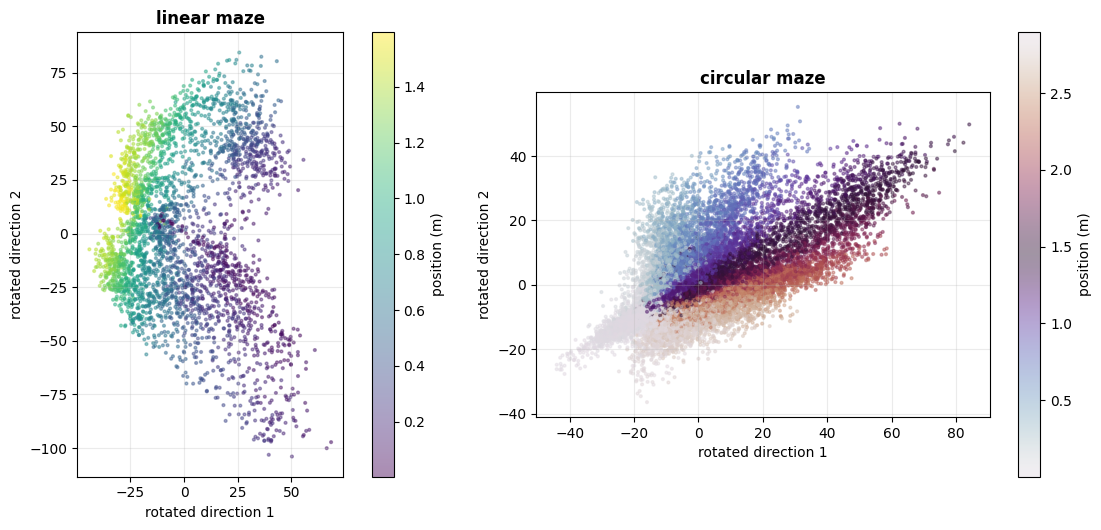

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
for ax, name in zip(axes, ('linear', 'circular')):
    z, wpos, sv = emb[name]
    cmap = 'twilight' if name == 'circular' else 'viridis'
    s = ax.scatter(z[:, 0], z[:, 1], c=wpos, s=4, alpha=0.45, cmap=cmap)
    plt.colorbar(s, ax=ax, label='position (m)')
    ax.set_xlabel('rotated direction 1'); ax.set_ylabel('rotated direction 2')
    ax.set_title(f"{name} maze", fontsize=12, fontweight='bold')
    ax.set_aspect('equal', 'box'); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**The circular maze's representation does not close into a ring.** Neither the
picture nor the numbers support the prediction: the radius coefficient of
variation, which would be *low* for a ring of roughly constant radius, is no
better for the circular maze than the linear one.

The tempting explanation is that the coordinate hid it. We hand the estimator
position as arc length, a number running 0 to the maximum, so it is asked to
predict a quantity in which the two endpoints are maximally far apart. A ring
would actively hurt that objective.

**That explanation is testable, and it is wrong.** Re-running the circular
session with position supplied as `(cos θ, sin θ)`, where the endpoints
genuinely are adjacent, makes the embedding *less* ring-like, not more: the
share of shared variance in the top two directions falls from about 88% to about
55%, so the structure spreads over more dimensions and a 2-D view captures less
of it.

So the honest conclusion is that **the ring is not recoverable here under either
encoding**, and the neat post-hoc story for why does not hold up either. A
plausible explanation for a null result deserves the same scrutiny as the
original claim.

What this does establish, usefully: **an embedding reflects the coordinate you
supply, not the intrinsic geometry of the represented space.** Reading a
manifold off an embedding plot is a natural thing to try and a shakier
inference than it looks.

## 8. What these recordings cannot tell us

Being clear about the questions that stayed unanswered is part of the result.

**Direction.** "Do the spikes lead the position, or follow it?" is the obvious
next question, and this data does not support an answer. Transfer entropy, the
standard tool, is a difference of two larger estimates; Tutorial 6 measures its
amplification at 25 to 40 times and shows its reported direction reversing when
the history window changes, on a system whose true answer we know. The
unconditioned alternative, `cross_predictive_information`, is a single estimate
and well behaved, but its directional asymmetry on comparable recordings is
smaller than the seed-to-seed variation, so the sign is not determined. Two
quantities, two different reasons, same verdict.

**Self-prediction and intrinsic timescale.** The quantities of Tutorial 5 slide
a window along the raw index, which is unsafe on a signal that exists in
fragments of a few seconds. Tutorial 10 asks those questions of a continuously
sampled recording instead.

**The comparison between the two mazes.** At a matched neuron count the linear
session gives a higher estimate, and it is not interpretable as an environment
effect: the two are estimated over very different window populations, retention
differs by roughly fivefold, the environments differ in size, and they are
separate sessions. The circular session earns its place here as a
**replication** rather than as a contrast, and replicating the split-leakage
result and the null in an independent recording is worth more than a comparison
that cannot be cleanly made.

## Key Takeaways

- Check `window_retention` before reading any estimate from real data. A
  per-window figure describes the retained windows, which are a selected subset.
- A window is usable only where every signal it pairs has data, so gaps in one
  signal remove windows for all of them.
- Quantities that slide a window along the raw index are unsafe on fragmented
  recordings. Ones that pair windows over the same interval are fine.
- Both populations carry position information at one to two orders of magnitude
  above a permutation null. With 30 permutations the smallest reportable p is
  about 0.03; the count sets the floor, not the effect.
- Random splitting on 75%-overlapping windows inflates the estimate in both
  recordings by a similar amount. That it replicates across independent sessions
  is what makes it convincing.
- Information grows roughly logarithmically with population size and does not
  saturate in range, with the estimator ceiling ruled out via `test_saturation`.
- Position information is untouched by jitter well below the window size and
  collapses only at several times it: a rate code at the window scale.
- `mode='precision'` needs unbinned spikes and `corruption_method='noise'`.
  Binning leaves no timing to corrupt and yields a flat line that looks like a
  finding.
- An embedding reflects the coordinate you supply. The circular maze's ring was
  not recoverable, and the obvious explanation for why was itself wrong.

## Common Mistakes

1. **Reporting an estimate without its retention.** Ten percent retention is
   fine and needs saying.
2. **Reading bits per window as bits.** The window is part of the quantity;
   windowed MI is extensive (Tutorial 4).
3. **Choosing a window longer than the data's contiguous stretches.** On the
   linear session almost nothing exceeds a few seconds.
4. **Using `Split(mode='random')` on overlapping windows.** Measured here in two
   recordings.
5. **Selecting neurons by firing rate or variance.** That selects on a statistic
   correlated with what you are measuring. Draw at random.
6. **Reading a bending scaling curve as saturation** without checking
   `test_saturation` first.
7. **Running `mode='precision'` on binned spikes.** It returns a clean, flat,
   meaningless curve and no error.
8. **Reading a manifold off an embedding plot.** The axes are arbitrary before
   rotation, and the geometry follows the coordinate you supplied.
9. **Treating a handful of permutations as a p-value.** Thirty gives a floor of
   about 0.03.

## What's Next

Tutorial 10 takes the same discipline to a different dataset: three brain areas
recorded under two conditions, where the questions are about how areas relate to
each other rather than to behaviour, and where a continuously sampled recording
allows the timescale questions this one could not ask.